<a href="https://colab.research.google.com/github/SaiKoushik1825/Deep-Learning/blob/main/DL_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
def step(x):
  return 1 if x>=0 else 0
class perceptron:
  def __init__(self,weights,bias):
    self.weights=weights
    self.bias=bias
  def predict(self,inputs):
    total=np.dot(self.weights,inputs)+self.bias
    return step(total)
weights = np.array([1, 1])
bias =-1.5
print("And gate")
And_gate=perceptron(weights,bias)
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", And_gate.predict(np.array(x)))
print("Or gate")
Or_gate=perceptron(weights,-1)
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", Or_gate.predict(np.array(x)))

And gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1
Or gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_and, x) + self.b_and)

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))


XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_nand = np.array([1, 1])
        self.b_nand = -1.5

        self.w_out = np.array([-1, 2])
        self.b_out = 0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)
        h2 = step(np.dot(self.w_nand, x) + self.b_nand)

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))


XOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


Learning Rate: 0.01, Final Loss: 0.240571
Learning Rate: 0.05, Final Loss: 0.012541
Learning Rate: 0.1, Final Loss: 0.002546
Learning Rate: 0.5, Final Loss: 0.000293
Learning Rate: 1.0, Final Loss: 0.000135


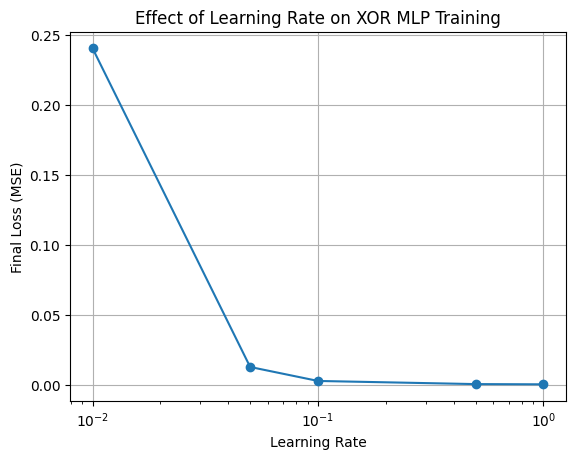

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 10000

for lr in learning_rates:

    np.random.seed(42)

    W1 = np.random.rand(2, 2)
    b1 = np.random.rand(1, 2)

    W2 = np.random.rand(2, 1)
    b2 = np.random.rand(1, 1)

    for epoch in range(epochs):

        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)

        error = y - y_pred
        loss = np.mean(error ** 2)

        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr

        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris=load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)

perceptron=Perceptron()

perceptron.fit(X_train,y_train)

y_pred1=perceptron.predict(X_test)

accuracy_score(y_test,y_pred1)

0.8

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

iris =load_breast_cancer()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9824561403508771


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8690 - loss: 0.4467 - val_accuracy: 0.9622 - val_loss: 0.1191
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9649 - loss: 0.1108 - val_accuracy: 0.9682 - val_loss: 0.0986
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9768 - loss: 0.0744 - val_accuracy: 0.9745 - val_loss: 0.0879
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9838 - loss: 0.0526 - val_accuracy: 0.9737 - val_loss: 0.0898
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9879 - loss: 0.0400 - val_accuracy: 0.9785 - val_loss: 0.0821
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9905 - loss: 0.0309 - val_accuracy: 0.9763 - val_loss: 0.0911
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.9785 - val_loss: 0.0820
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.0224 - 

WEEK 3


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


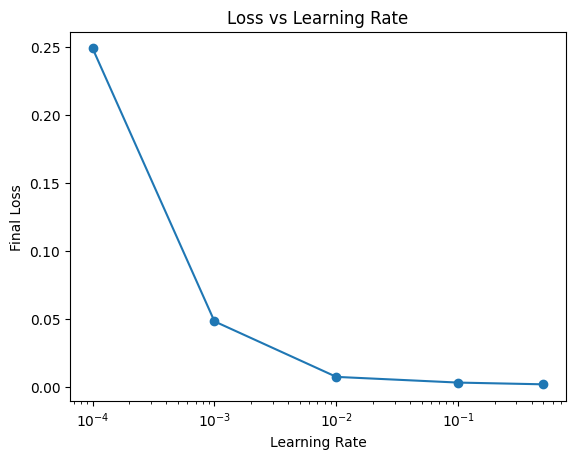

In [ ]:
#9
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
losses = []

for lr in learning_rates:
    mlp = MLPClassifier(hidden_layer_sizes=(10,),
                        learning_rate_init=lr,
                        max_iter=500,
                        random_state=42)

    mlp.fit(X_train, y_train)
    losses.append(mlp.loss_)

# Plot
plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.xscale('log')
plt.show()

In [ ]:
#11
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_breast_cancer()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1]
accuracies = []

for lr in learning_rates:
    model = Perceptron(eta0=lr,
                       max_iter=1000,
                       random_state=42,
                       tol=1e-3)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Learning Rate: {lr}, Accuracy: {acc}")

Learning Rate: 0.0001, Accuracy: 0.9766081871345029
Learning Rate: 0.001, Accuracy: 0.9766081871345029
Learning Rate: 0.01, Accuracy: 0.9707602339181286
Learning Rate: 0.1, Accuracy: 0.9707602339181286


In [ ]:
#12
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Try different hidden layers and iterations
mlp = MLPClassifier(hidden_layer_sizes=(50,50),
                    learning_rate_init=0.001,
                    max_iter=500,
                    activation='relu',
                    solver='adam',
                    random_state=42)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9703703703703703


WEEK 5

In [ ]:
#15
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models, regularizers
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()
model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8282 - loss: 1.2496 - val_accuracy: 0.9174 - val_loss: 0.5603
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9148 - loss: 0.5500 - val_accuracy: 0.9300 - val_loss: 0.4739
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9288 - loss: 0.4715 - val_accuracy: 0.9432 - val_loss: 0.4167
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9336 - loss: 0.4381 - val_accuracy: 0.9451 - val_loss: 0.3928
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9386 - loss: 0.4069 - val_accuracy: 0.9471 - val_loss: 0.3683
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9415 - loss: 0.3836 - val_accuracy: 0.9509 - val_loss: 0.3550
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9413 - loss: 0.3692 - val_accuracy: 0.9459 - val_loss: 0.3515
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9473 - loss: 0.3474 - 

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

datagen.fit(x_train)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6628 - loss: 1.7209 - val_accuracy: 0.9266 - val_loss: 0.6979
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8669 - loss: 0.8482 - val_accuracy: 0.9408 - val_loss: 0.5868
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8861 - loss: 0.7397 - val_accuracy: 0.9441 - val_loss: 0.5294
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8943 - loss: 0.6755 - val_accuracy: 0.9326 - val_loss: 0.5201
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9009 - loss: 0.6286 - val_accuracy: 0.9426 - val_loss: 0.4845
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9047 - loss: 0.6047 - val_accuracy: 0.9512 - val_loss: 0.4496
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9048 - loss: 0.5902 - val_accuracy: 0.9324 - val_loss: 0.4617
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9060 -